<a href="https://colab.research.google.com/github/Rijalpratama23/PengolahanCitraDigital/blob/main/Copy_of_Frekuensi_Transform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Fourier Transform**

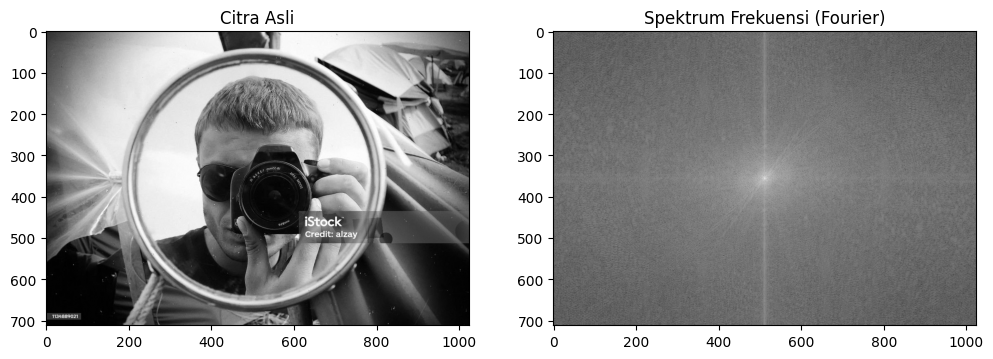

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca citra dalam grayscale
img = cv2.imread('sampel.jpg', 0)

# Terapkan Fourier Transform
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)  # pusatkan frekuensi rendah di tengah
magnitude_spectrum = 20 * np.log(np.abs(fshift))

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Citra Asli')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Spektrum Frekuensi (Fourier)')
plt.imshow(magnitude_spectrum, cmap='gray')
plt.show()

**Contoh FFT High - Pass**

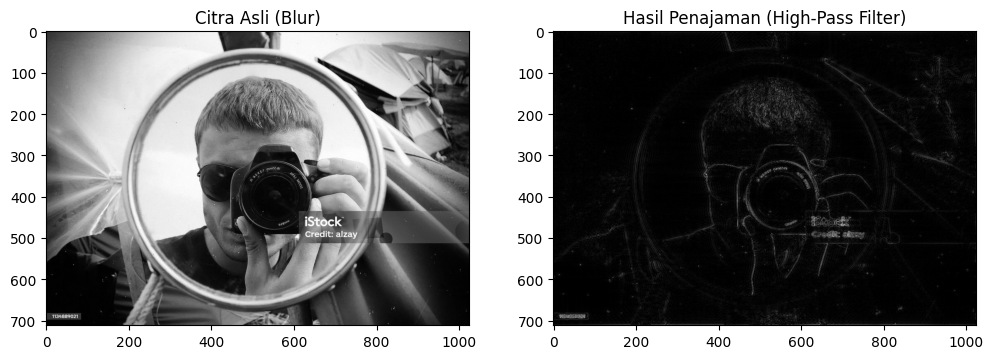

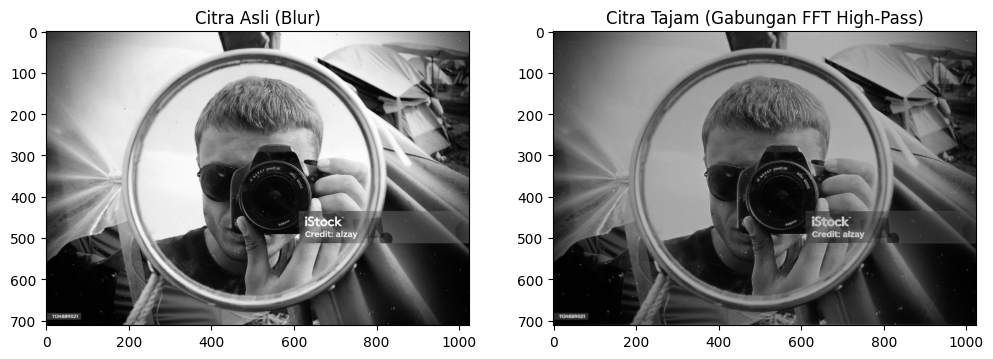

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar grayscale
img = cv2.imread('sampel.jpg', 0)

# Ubah ke domain frekuensi (FFT)
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

# Buat filter high-pass (frekuensi tinggi)
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# Ukuran area tengah (low frequency) yang akan dihapus
mask = np.ones((rows, cols), np.uint8)
r = 90 # semakin besar r, semakin halus hasilnya
mask[crow - r:crow + r, ccol - r:ccol + r] = 0

# Terapkan mask high-pass
fshift_hp = fshift * mask

# Kembalikan ke domain spasial (Inverse FFT)
f_ishift = np.fft.ifftshift(fshift_hp)
img_hp = np.abs(np.fft.ifft2(f_ishift))

# Setelah kamu dapatkan img_hp (hasil high-pass)
# Gabungkan dengan citra asli agar tampak lebih tajam
sharpened = cv2.addWeighted(img, 0.7, img_hp.astype(np.uint8), 0.7, 0)




#  Bandingkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Citra Asli (Blur)')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Hasil Penajaman (High-Pass Filter)')
plt.imshow(img_hp, cmap='gray')
plt.show()

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Citra Asli (Blur)')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Citra Tajam (Gabungan FFT High-Pass)')
plt.imshow(sharpened, cmap='gray')
plt.show()


**Contoh FFT - Low Pass**

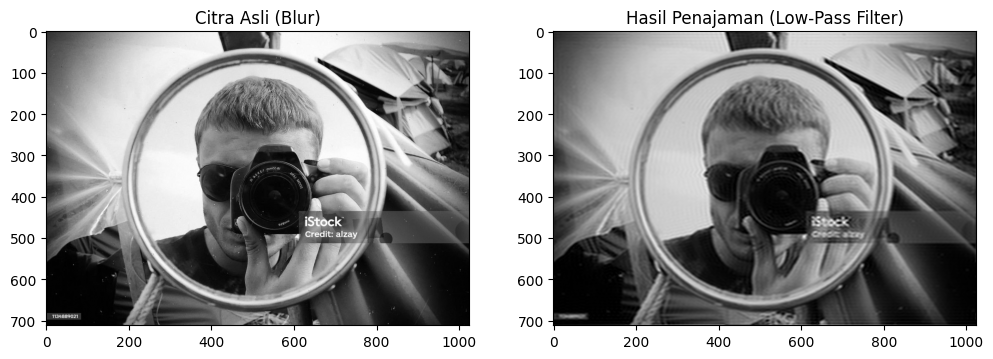

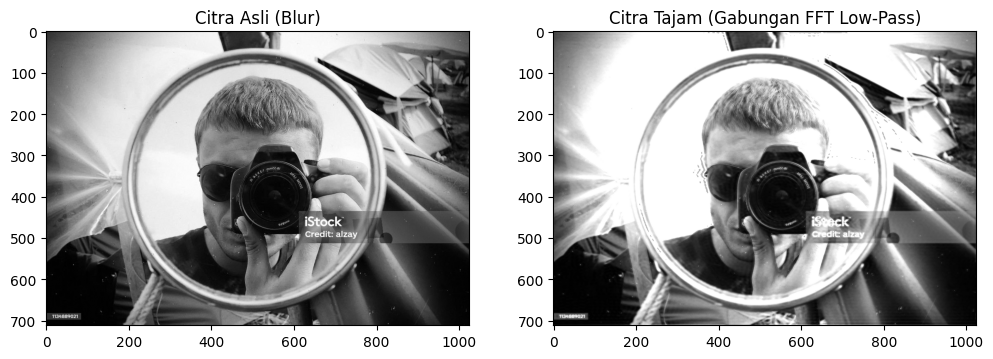

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar grayscale
img = cv2.imread('sampel.jpg', 0)

# Ubah ke domain frekuensi (FFT)
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

rows, cols = img.shape
crow, ccol = rows//2, cols//2
mask = np.zeros((rows, cols), np.uint8)
r = 90  # radius area tengah yang disimpan
mask[crow-r:crow+r, ccol-r:ccol+r] = 1

# apply mask
fshift_lp = fshift * mask


# Kembalikan ke domain spasial (Inverse FFT)
f_ishift = np.fft.ifftshift(fshift_lp)
img_hp = np.abs(np.fft.ifft2(f_ishift))

# Setelah kamu dapatkan img_hp (hasil high-pass)
# Gabungkan dengan citra asli agar tampak lebih tajam
sharpened = cv2.addWeighted(img, 0.7, img_hp.astype(np.uint8), 0.7, 0)


#  Bandingkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Citra Asli (Blur)')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Hasil Penajaman (Low-Pass Filter)')
plt.imshow(img_hp, cmap='gray')
plt.show()

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Citra Asli (Blur)')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Citra Tajam (Gabungan FFT Low-Pass)')
plt.imshow(sharpened, cmap='gray')
plt.show()


**RGB High Pass**

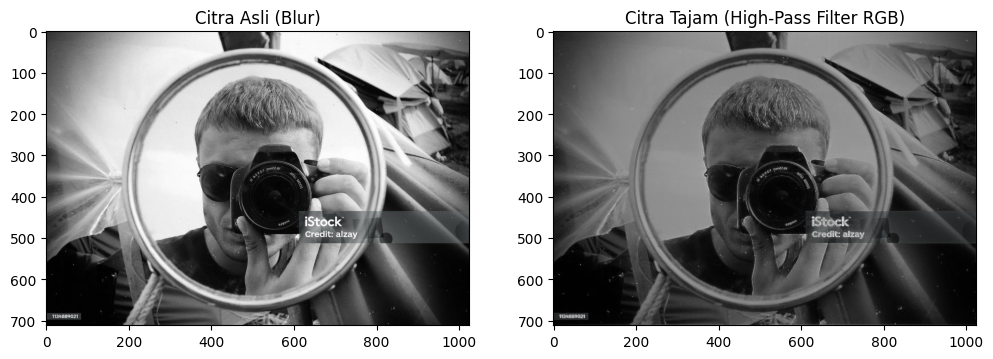

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar berwarna
img = cv2.imread('sampel.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # ubah dari BGR ke RGB

# Siapkan parameter filter
rows, cols, _ = img.shape
crow, ccol = rows // 2, cols // 2
r = 90  # radius low frequency yang dihapus

# Buat mask high-pass (1 channel)
mask = np.ones((rows, cols), np.uint8)
mask[crow - r:crow + r, ccol - r:ccol + r] = 0

# Lakukan FFT untuk setiap channel warna
channels_hp = []
for i in range(3):  # R, G, B
    f = np.fft.fft2(img[:, :, i])
    fshift = np.fft.fftshift(f)
    fshift_hp = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_hp)
    img_hp = np.abs(np.fft.ifft2(f_ishift))
    channels_hp.append(img_hp)

#  Gabungkan hasil 3 channel
img_hp_color = cv2.merge(channels_hp)
img_hp_color = cv2.normalize(img_hp_color, None, 0, 255, cv2.NORM_MINMAX)
img_hp_color = img_hp_color.astype(np.uint8)

# Gabungkan citra asli + hasil HPF agar tampak tajam
sharpened = cv2.addWeighted(img, 0.6, img_hp_color, 0.6, 0)

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Citra Asli (Blur)')
plt.imshow(img)

plt.subplot(1,2,2)
plt.title('Citra Tajam (High-Pass Filter RGB)')
plt.imshow(sharpened)
plt.show()


**2. Discrete Cosine Transform (DCT)**

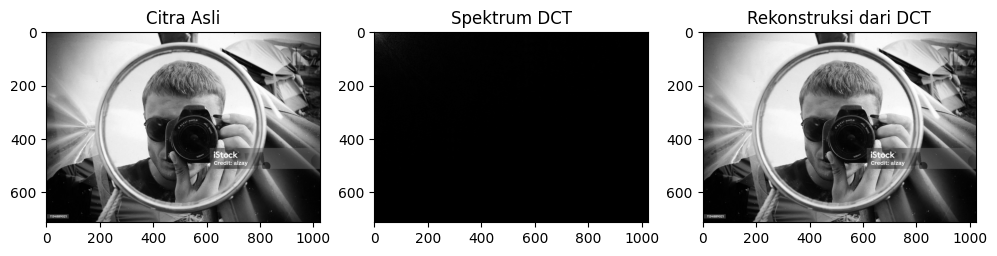

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Baca citra grayscale
img = cv2.imread('sampel.jpg', 0)
img = np.float32(img) / 255.0  # normalisasi ke [0,1]

# Terapkan DCT
dct = cv2.dct(img)
dct_log = np.log(abs(dct) + 1)  # untuk tampilan visual

# Terapkan Inverse DCT (rekonstruksi citra)
idct = cv2.idct(dct)

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title('Citra Asli')
plt.imshow(img, cmap='gray')

plt.subplot(1,3,2)
plt.title('Spektrum DCT')
plt.imshow(dct_log, cmap='gray')

plt.subplot(1,3,3)
plt.title('Rekonstruksi dari DCT')
plt.imshow(idct, cmap='gray')
plt.show()

**3. Wavelet Transform**

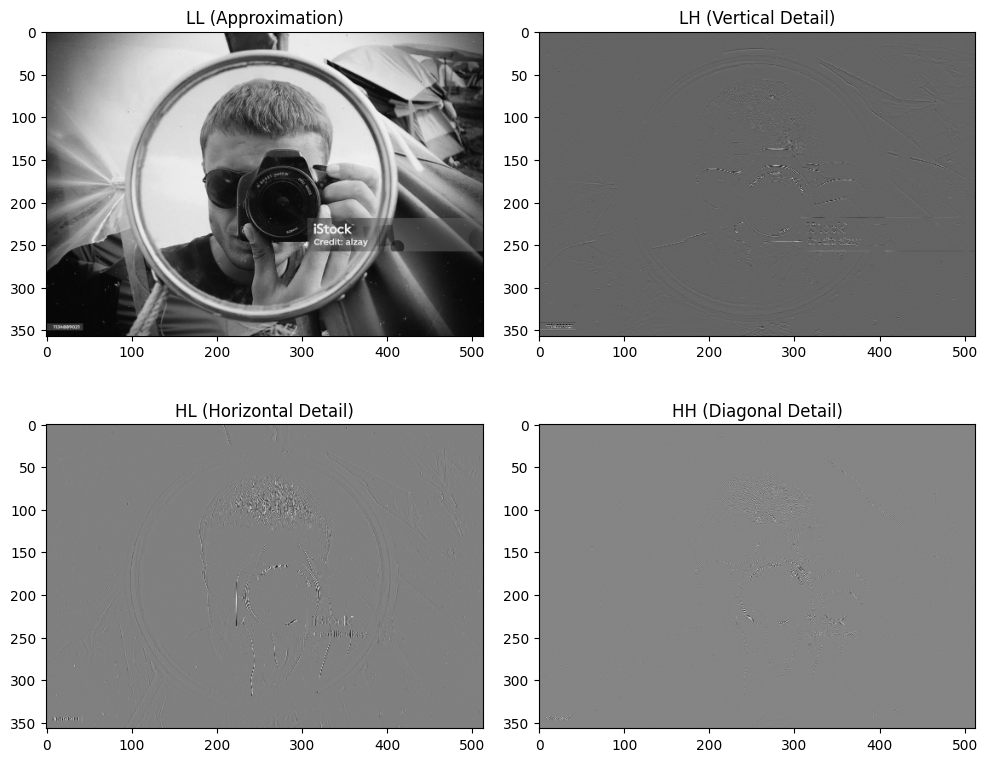

In [6]:
import cv2
import pywt
import matplotlib.pyplot as plt

# Baca citra grayscale
img = cv2.imread('sampel.jpg', 0)

# Terapkan DWT (Discrete Wavelet Transform)
# coeffs2 = pywt.dwt2(img, 'haar')  # gunakan wavelet Haar
# LL, (LH, HL, HH) = coeffs2

# coeffs3 = pywt.dwt2(img, 'db1')  # gunakan wavelet Daubechies
# LL, (LH, HL, HH) = coeffs3

coeffs4 = pywt.dwt2(img, 'sym2')  # gunakan wavelet Sym
LL, (LH, HL, HH) = coeffs4

# Tampilkan hasil
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.title('LL (Approximation)')
plt.imshow(LL, cmap='gray')

plt.subplot(2,2,2)
plt.title('LH (Vertical Detail)')
plt.imshow(LH, cmap='gray')

plt.subplot(2,2,3)
plt.title('HL (Horizontal Detail)')
plt.imshow(HL, cmap='gray')

plt.subplot(2,2,4)
plt.title('HH (Diagonal Detail)')
plt.imshow(HH, cmap='gray')

plt.tight_layout()
plt.show()
